In [1]:
    !wget https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz

--2026-03-02 05:54:18--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.7, 130.14.250.10, 130.14.250.11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.7|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 434440118 (414M) [application/x-gzip]
Saving to: ‘variant_summary.txt.gz’

variant_summary.txt 100%[===================>] 414.31M   186MB/s    in 2.2s    

2026-03-02 05:54:20 (186 MB/s) - ‘variant_summary.txt.gz’ saved [434440118/434440118]



In [3]:
df = pd.read_csv(
    "variant_summary.txt.gz",
    sep="\t",
    compression="gzip",
    low_memory=False,
    nrows=100000
)

In [5]:
df["Assembly"].value_counts()

,count
Assembly,
GRCh38,49698


In [6]:
df = df[df["Assembly"] == "GRCh38"]

In [7]:
cols = [
    "GeneSymbol",
    "ClinicalSignificance",
    "ReviewStatus",
    "Type",
    "OriginSimple",
    "Assembly"
]

df = df[cols]

In [8]:
valid_labels = [
    "Pathogenic",
    "Likely pathogenic",
    "Benign",
    "Likely benign"
]

df = df[df["ClinicalSignificance"].isin(valid_labels)]

In [9]:
df["label"] = df["ClinicalSignificance"].map({
    "Pathogenic": 1,
    "Likely pathogenic": 1,
    "Benign": 0,
    "Likely benign": 0
})

In [10]:
df["label"].value_counts()

,count
label,
1,22189
0,4295


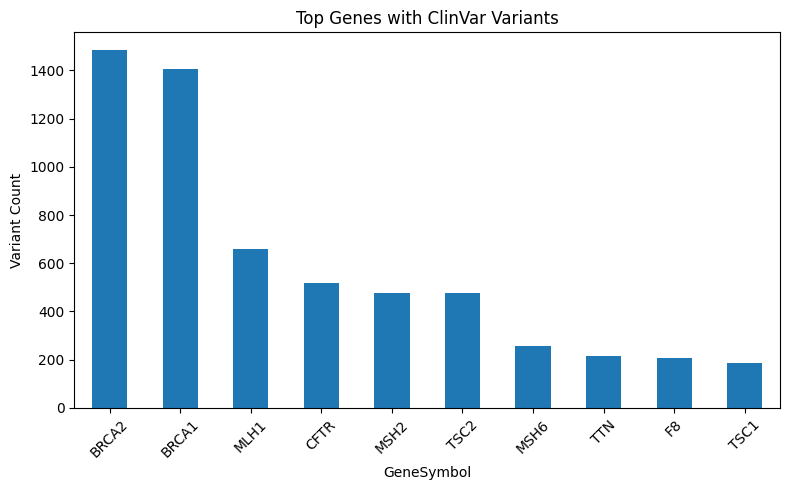

In [11]:
import matplotlib.pyplot as plt

top_genes = df["GeneSymbol"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_genes.plot(kind="bar")
plt.title("Top Genes with ClinVar Variants")
plt.ylabel("Variant Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("clinvar_top_genes.png", dpi=300)
plt.show()

In [12]:
pd.crosstab(df["Type"], df["label"])

label,0,1
Type,,
Deletion,51,4010
Duplication,42,1341
Indel,4,325
Insertion,5,207
Inversion,1,10
Microsatellite,51,625
Translocation,0,2
copy number gain,75,598
copy number loss,69,1123


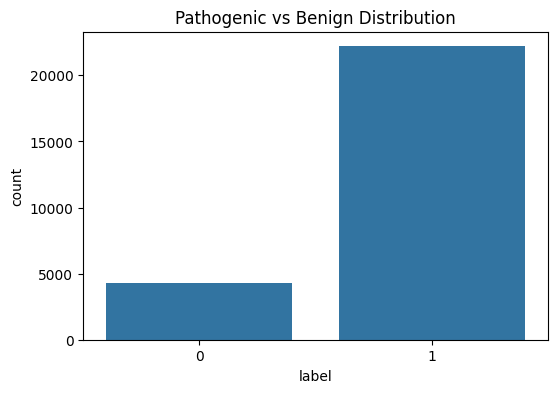

In [13]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label")
plt.title("Pathogenic vs Benign Distribution")
plt.savefig("pathogenic_vs_benign.png", dpi=300)
plt.show()

In [14]:
df["ReviewStatus"].value_counts().head(10)

,count
ReviewStatus,
no assertion criteria provided,7660
"criteria provided, multiple submitters, no conflicts",7044
"criteria provided, single submitter",6391
reviewed by expert panel,5365
practice guideline,24


# Variant Curation Quality Assessment

ClinVar variants differ in their level of supporting evidence. In this dataset, most variants fall under “no assertion criteria provided” or “criteria provided, multiple submitters, no conflicts.” A smaller subset has been reviewed by expert panels, representing higher confidence classifications.

This variation in review status highlights that clinical labels in ClinVar are not uniform in evidentiary strength. Therefore, interpretation of pathogenicity should consider curation level alongside the classification itself.